In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
df = df[df['Desired_Savings'] > 0].copy()


df['Taxa_Endividamento'] = df['Loan_Repayment'] / df['Income']
df['Fracasso_Poupanca'] = (df['Disposable_Income'] < df['Desired_Savings']).astype(int)


df['Vulnerable'] = ((df['Taxa_Endividamento'] > 0.15) | (df['Fracasso_Poupanca'] == 1)).astype(int)




df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Groceries_Ratio'] = df['Groceries'] / df['Income']
df['Transport_Ratio'] = df['Transport'] / df['Income']
df['Utilities_Ratio'] = df['Utilities'] / df['Income']
df['Insurance_Ratio'] = df['Insurance'] / df['Income']

df['Eating_Out_Ratio'] = df['Eating_Out'] / df['Income']
df['Entertainment_Ratio'] = df['Entertainment'] / df['Income']
df['Misc_Ratio'] = df['Miscellaneous'] / df['Income']



features = [
    'Age', 'Dependents',                 # Demografia
    'Rent_Ratio', 'Healthcare_Ratio',    # Essenciais
    'Education_Ratio', 'Groceries_Ratio',
    'Transport_Ratio', 'Utilities_Ratio', 
    'Insurance_Ratio',
    'Eating_Out_Ratio', 'Entertainment_Ratio', # Lazer/Supérfluos
    'Misc_Ratio'
]

X = df[features]
y = df['Vulnerable']

# Divisão
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

--- Nova Distribuição Absoluta ---
Vulnerable
0    17312
1     2576
Name: count, dtype: int64

--- Nova Distribuição Percentual (%) ---
Vulnerable
0    87.05
1    12.95
Name: proportion, dtype: float64


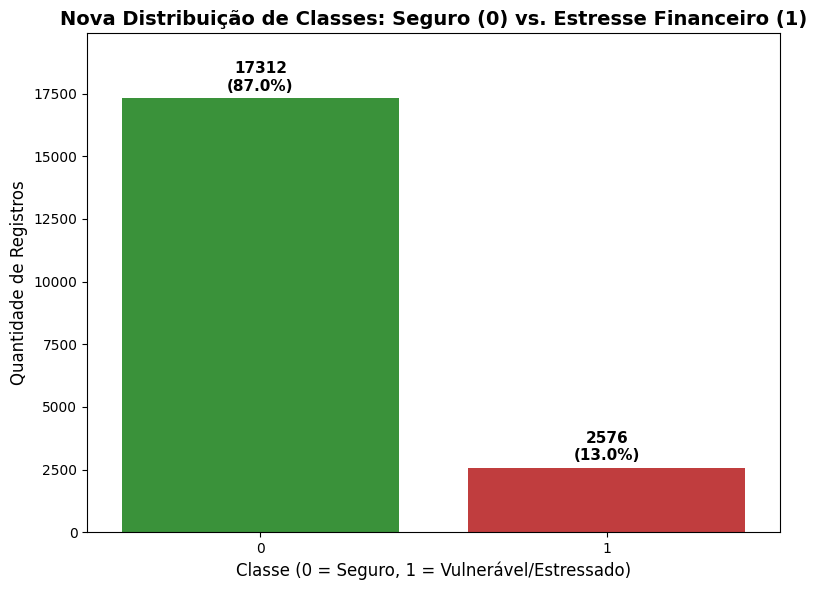

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculando a distribuição absoluta e percentual
contagem = df['Vulnerable'].value_counts()
percentual = df['Vulnerable'].value_counts(normalize=True) * 100

print("--- Nova Distribuição Absoluta ---")
print(contagem)
print("\n--- Nova Distribuição Percentual (%) ---")
print(percentual.round(2))

# 2. Visualização gráfica da distribuição
plt.figure(figsize=(8, 6))

# Gráfico de barras com as novas classes
ax = sns.countplot(
    x='Vulnerable', 
    data=df, 
    palette=['#2ca02c', '#d62728'], # Verde (Seguro), Vermelho (Vulnerável)
    hue='Vulnerable',
    legend=False
)

# Adicionando os rótulos de dados
total = len(df)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        porcentagem = f'{(altura/total)*100:.1f}%'
        texto = f'{int(altura)}\n({porcentagem})'
        ax.annotate(
            texto, 
            (p.get_x() + p.get_width() / 2., altura),
            ha='center', 
            va='center', 
            xytext=(0, 15), 
            textcoords='offset points',
            fontsize=11, 
            fontweight='bold'
        )

plt.title('Nova Distribuição de Classes: Seguro (0) vs. Estresse Financeiro (1)', fontsize=14, fontweight='bold')
plt.xlabel('Classe (0 = Seguro, 1 = Vulnerável/Estressado)', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)

# Espaço extra no topo para as anotações não cortarem
plt.ylim(0, df['Vulnerable'].value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

--- Configuração do Modelo ---
Scale Pos Weight Aplicado: 6.72

Treinando o modelo XGBoost com as novas features de comportamento...


c:\Users\mathe\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:46:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.87      0.59      0.71      3463
           1       0.13      0.42      0.20       515

    accuracy                           0.57      3978
   macro avg       0.50      0.51      0.45      3978
weighted avg       0.78      0.57      0.64      3978



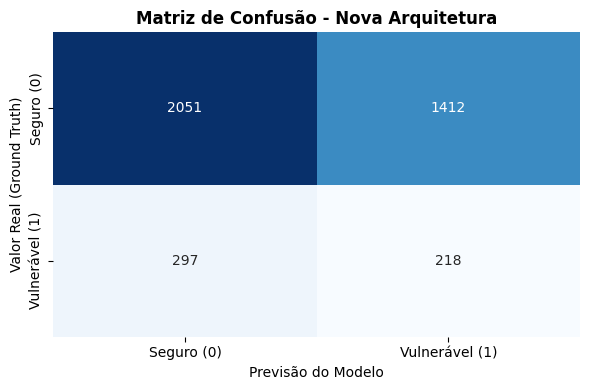

In [4]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cálculo do peso exato da nova distribuição
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
peso_balanceamento = num_neg / num_pos

print(f"--- Configuração do Modelo ---")
print(f"Scale Pos Weight Aplicado: {peso_balanceamento:.2f}\n")

# 2. Configurando o XGBoost com a nova arquitetura
modelo_xgb = xgb.XGBClassifier(
    scale_pos_weight=peso_balanceamento,
    n_estimators=150,       # Aumentei levemente para dar mais tempo de aprendizado
    learning_rate=0.1,
    max_depth=3,            # Profundidade ideal para evitar overfitting
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 3. Treinamento
print("Treinando o modelo XGBoost com as novas features de comportamento...")
modelo_xgb.fit(X_train, y_train)

# 4. Previsões no conjunto de teste
y_pred = modelo_xgb.predict(X_test)

# 5. Avaliação de Desempenho
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# 6. Visualização da Matriz de Confusão
plt.figure(figsize=(6, 4))
matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Seguro (0)', 'Vulnerável (1)'], 
            yticklabels=['Seguro (0)', 'Vulnerável (1)'])
plt.title('Matriz de Confusão - Nova Arquitetura', fontweight='bold', fontsize=12)
plt.ylabel('Valor Real (Ground Truth)')
plt.xlabel('Previsão do Modelo')
plt.tight_layout()
plt.show()